# How Much of "Real Estate" Growth Is Just Imputed Rent?

**A quantitative study of imputed owner-occupier rents vs. genuine real-estate market activity,
using OECD national accounts and house-price data, DuckDB, statistics, and machine learning.**

---

### The problem

National accounts record the "rent" that owner-occupiers would notionally pay themselves as
**output of the real estate industry** — even though no transaction, tenant, agent, or job is
involved. This is standard, defensible SNA/ESA methodology (it makes housing consumption
comparable across owners and renters), but it means a headline like *"real estate contributed
X% to GDP growth"* can be substantially a valuation exercise rather than market activity —
brokerage, letting, property management, development services.

### The question this notebook answers

For every country and year where OECD national accounts separately report the two components,
we split **Real estate activities (ISIC L68)** into:

- **L68A — Imputed rents of owner-occupied dwellings** (notional, non-market)
- **L68B — Real estate activities excluding imputed rents** (brokerage, letting, management,
  development — genuine market services)

and ask: *how large is the imputed share, is it rising, what drives it, and can it be forecast?*

### Method at a glance

| Stage | Tool |
|---|---|
| Data acquisition | OECD.Stat SDMX REST API (National Accounts + Analytical House Price Indicators) |
| Cleaning & analytical tables | **DuckDB** (SQL, columnar, in-process) |
| Statistical inference | trend regressions, paired hypothesis tests, correlation analysis (`scipy`, `statsmodels`) |
| Machine learning | **XGBoost** vs. linear regression vs. naive baseline, grouped cross-validation |
| Explainability | **SHAP** (SHapley Additive exPlanations) |
| Deep learning | a compact PyTorch feed-forward network, honestly benchmarked against the above |
| Forecasting | walk-forward-backtested trend / damped-trend extrapolation to 2030 |

All figures in this notebook are computed live from the data pulled in Section 1 — nothing is
hand-typed. Re-running the notebook top to bottom reproduces every number and chart.

## 1. Setup

Libraries, plotting style, and file paths. The chart palette below follows a fixed
categorical order (color assigned **by entity, never by rank**) so the same country always
gets the same color across every chart in this notebook.

In [1]:
import json
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

# --- fixed categorical palette (validated for CVD-safety; see dataviz skill) ---
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"

# Fixed country -> color assignment used throughout (identity, not rank)
COUNTRY_COLOR = {"CZE": PALETTE["blue"], "USA": PALETTE["orange"], "GBR": PALETTE["aqua"]}
COUNTRY_NAME = {"CZE": "Czechia", "USA": "United States", "GBR": "United Kingdom"}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID, "grid.linewidth": 0.7,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.axisbelow": True, "figure.dpi": 110,
})

print("Environment ready.")
print(f"Project root: {ROOT}")

Environment ready.
Project root: /home/moritus-peters/Documents/Real_estate_growth_and_economimc_active


## 1a. Plain-language primer — read this first if statistics isn't your daily language

Everything below still uses precise technical terms (that's what makes the numbers trustworthy),
but here's what the recurring words actually mean, in the language you'd use at the market or
over the fence with a neighbor:

| Technical word | What it actually means |
|---|---|
| **Imputed rent** | The "pretend rent" a homeowner is scored as paying to *themselves*. If you own your house outright, no cash changes hands — but the government's accountants still write down a rent payment for it, as if you were your own tenant, and count that pretend payment as part of the country's economic output. |
| **Real estate activities (excl. imputed)** | The *actual* money-changing-hands part of the property business: agents' commissions, letting fees, property management, developers building and selling. Real people doing real jobs for real money. |
| **Value added / GDP** | The size of the economic pie — everything of value the country produced this year, add up. |
| **Share / percentage point (pp)** | If something is "60%" of a total, that's its *share*. When a share moves from 60% to 65%, we say it rose **"5 percentage points,"** *not* "5%" — 5% would mean a much smaller move (60 → 63). Watch for this distinction; news headlines often blur it. |
| **CAGR (compound annual growth rate)** | The steady yearly growth rate that would get you from the start value to the end value — the same idea as the interest rate on a savings account that compounds every year. |
| **Nominal vs. real (or "volume")** | *Nominal* = the raw currency amount, including any effect of prices going up. *Real* = with the effect of rising prices stripped out, showing whether the actual *amount of activity* grew. A shop's nominal sales can rise just because it raised prices, with the same number of customers — real/volume growth asks whether more customers actually came in. |
| **Median** | Line up every country from lowest to highest on some number — the median is whoever is standing exactly in the middle. It's a more honest "typical value" than an average, which can be dragged around by one extreme country. |
| **Correlation (r)** | A score from -1 to +1 for "do these two things move together?" +1 = perfectly together, 0 = no relationship at all, -1 = perfectly opposite. r = 0.30 means "somewhat related, but plenty of other things are going on too" — not a strong link. |
| **Statistically significant (p-value)** | A p-value is roughly "the odds this pattern is just random noise." p < 0.05 is the usual bar for "probably a real pattern, not a fluke" — like flipping a coin and being surprised it's not close to 50/50. |
| **SHAP value** | A way of asking a prediction model "which ingredient gets the credit or blame for this specific answer?" — like a chef breaking down which spice made a dish taste the way it did, dish by dish. |
| **Forecast confidence band** | The shaded zone around a forecast line — it's the honest way of saying *"our best guess is the middle line, but don't hold us to the exact number; anywhere in this shaded range wouldn't surprise us."* |

Keep this table open — every section below leans on these words, and each major finding also gets
a short **"In everyday terms"** note that translates the specific result, no jargon required.

## 2. Data acquisition — OECD SDMX APIs

Two public, no-key-required OECD dataflows:

1. **`OECD.SDD.NAD:DSD_NASU@DF_USEVA_T1600`** — Use table including value added ("Table 1600").
   We pull `TRANSACTION=B1G` (Value added, gross) for `ACTIVITY ∈ {_T, L, L68A, L68B}` — i.e.
   total-economy value added, total real estate, imputed rents, and real estate excluding
   imputed rents — in both **current prices (`V`)** and **previous-year prices (`Y`)** (the
   latter lets us chain-link a genuine *volume* growth rate later, isolating price effects
   from real activity).
2. **`OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRICES`** — Analytical House Price Indicators:
   nominal house prices (`HPI`), real house prices (`RHP`), the rent price index (`RPI`), and
   the house-price-to-income ratio (`HPI_YDH`) — used later as external, independent checks on
   what the national-accounts imputed-rent series is actually tracking.

Results are cached to `data/raw/` — re-running this cell will not re-hit the API if the files
already exist.

In [2]:
import requests

HEADERS = {"Accept": "application/vnd.sdmx.data+csv;file=true;labels=both"}

def fetch_if_missing(url, params, out_path, label):
    if out_path.exists():
        print(f"[cache] {label}: using {out_path.name} ({out_path.stat().st_size:,} bytes)")
        return
    print(f"[fetch] {label} ...")
    r = requests.get(url, params=params, headers=HEADERS, timeout=180)
    r.raise_for_status()
    out_path.write_text(r.text, encoding="utf-8")
    print(f"        OK ({len(r.text):,} bytes)")

# --- National accounts: value added by activity, all countries, all years ---
key = ".".join(["A", "", "B1G", "L68A+L68B+L+_T", "", "", "", "V+Y", ""])
url = f"https://sdmx.oecd.org/public/rest/data/OECD.SDD.NAD,DSD_NASU@DF_USEVA_T1600,/{key}"
fetch_if_missing(url, {"dimensionAtObservation": "AllDimensions"},
                  RAW / "oecd_nad_value_added.csv", "OECD National Accounts (real estate breakdown)")

# --- House price indicators, all countries, all years ---
key2 = ".".join(["", "A", "", ""])
url2 = f"https://sdmx.oecd.org/public/rest/data/OECD.ECO.MPD,DSD_AN_HOUSE_PRICES@DF_HOUSE_PRICES,/{key2}"
fetch_if_missing(url2, {"dimensionAtObservation": "AllDimensions"},
                  RAW / "oecd_house_prices.csv", "OECD Analytical House Price Indicators")

[cache] OECD National Accounts (real estate breakdown): using oecd_nad_value_added.csv (1,689,679 bytes)
[cache] OECD Analytical House Price Indicators: using oecd_house_prices.csv (2,744,425 bytes)


## 3. DuckDB — building the analytical fact table

OECD's `labels=both` CSV export encodes every dimension as `"CODE: Label"` in both the header
and the cell values. We load the raw files as all-`VARCHAR` DuckDB tables, split code from
label with `split_part`, cast, and **pivot the four activity codes into columns** so each row
is one (country, year, price base) observation with `imputed_rent`, `real_estate_excl_imputed`,
`real_estate_total`, and `gdp_basic_prices` side by side — the shape every later computation
needs.

In [3]:
DB_PATH = PROC / "real_estate.duckdb"
try:
    con = duckdb.connect(str(DB_PATH))
except duckdb.IOException:
    # Another kernel (e.g. an IDE session) already has the file open -- fall back
    # to an in-memory database for this run rather than fighting over the lock.
    print(f"[note] {DB_PATH.name} is locked by another session; using an in-memory DuckDB instead.")
    con = duckdb.connect(":memory:")
con.execute("PRAGMA disable_progress_bar")

con.execute(f"""
    CREATE OR REPLACE TABLE raw_value_added AS
    SELECT * FROM read_csv_auto('{RAW / "oecd_nad_value_added.csv"}', header=True, all_varchar=True)
""")
con.execute(f"""
    CREATE OR REPLACE TABLE raw_house_prices AS
    SELECT * FROM read_csv_auto('{RAW / "oecd_house_prices.csv"}', header=True, all_varchar=True)
""")

def clean_labeled_table(con, raw_table, clean_table, label_cols):
    cols = con.execute(f"PRAGMA table_info(\'{raw_table}\')").fetchdf()["name"].tolist()
    select_sql = []
    for raw_col in cols:
        base = raw_col.split(":")[0].strip()
        select_sql.append(f'trim(split_part("{raw_col}", \':\', 1)) AS {base}')
        if base in label_cols:
            select_sql.append(f'trim(split_part("{raw_col}", \':\', 2)) AS {base}_LABEL')
    con.execute(f"CREATE OR REPLACE TABLE {clean_table} AS SELECT {', '.join(select_sql)} FROM {raw_table}")

clean_labeled_table(con, "raw_value_added", "value_added_clean",
                     {"REF_AREA", "ACTIVITY", "TRANSACTION", "PRICE_BASE", "VALUATION", "UNIT_MEASURE"})
con.execute("ALTER TABLE value_added_clean ALTER COLUMN TIME_PERIOD TYPE INTEGER")
con.execute("ALTER TABLE value_added_clean ALTER COLUMN OBS_VALUE TYPE DOUBLE")
con.execute("ALTER TABLE value_added_clean ALTER COLUMN UNIT_MULT TYPE INTEGER")
con.execute("""
    CREATE OR REPLACE TABLE value_added_clean AS
    SELECT *, OBS_VALUE * POWER(10, UNIT_MULT) AS VALUE_ACTUAL FROM value_added_clean
""")

clean_labeled_table(con, "raw_house_prices", "house_prices_clean",
                     {"REF_AREA", "MEASURE", "UNIT_MEASURE", "ADJUSTMENT"})
con.execute("ALTER TABLE house_prices_clean ALTER COLUMN TIME_PERIOD TYPE INTEGER")
con.execute("ALTER TABLE house_prices_clean ALTER COLUMN OBS_VALUE TYPE DOUBLE")

print("value_added_clean: ", con.execute("SELECT COUNT(*) FROM value_added_clean").fetchone()[0], "rows")
print("house_prices_clean:", con.execute("SELECT COUNT(*) FROM house_prices_clean").fetchone()[0], "rows")

[note] real_estate.duckdb is locked by another session; using an in-memory DuckDB instead.


value_added_clean:  3846 rows
house_prices_clean: 11724 rows


In [4]:
# The analytical fact table: one row per (country, year, price_base), activities pivoted to columns.
con.execute("""
    CREATE OR REPLACE TABLE fact_real_estate AS
    WITH piv AS (
        SELECT
            REF_AREA, REF_AREA_LABEL, TIME_PERIOD, PRICE_BASE, PRICE_BASE_LABEL,
            MAX(CASE WHEN ACTIVITY = \'_T\'   THEN VALUE_ACTUAL END) AS gdp_basic_prices,
            MAX(CASE WHEN ACTIVITY = \'L\'    THEN VALUE_ACTUAL END) AS real_estate_total,
            MAX(CASE WHEN ACTIVITY = \'L68A\' THEN VALUE_ACTUAL END) AS imputed_rent,
            MAX(CASE WHEN ACTIVITY = \'L68B\' THEN VALUE_ACTUAL END) AS real_estate_excl_imputed
        FROM value_added_clean
        GROUP BY 1,2,3,4,5
    )
    SELECT *,
        CASE WHEN real_estate_total > 0 THEN imputed_rent / real_estate_total END AS imputed_share_of_re,
        CASE WHEN gdp_basic_prices > 0 THEN real_estate_total / gdp_basic_prices END AS re_share_of_gdp,
        CASE WHEN gdp_basic_prices > 0 THEN imputed_rent / gdp_basic_prices END AS imputed_share_of_gdp
    FROM piv
    WHERE real_estate_total IS NOT NULL
    ORDER BY REF_AREA, TIME_PERIOD, PRICE_BASE
""")

n_rows = con.execute("SELECT COUNT(*) FROM fact_real_estate").fetchone()[0]
n_countries = con.execute("SELECT COUNT(DISTINCT REF_AREA) FROM fact_real_estate WHERE PRICE_BASE=\'V\'").fetchone()[0]
print(f"fact_real_estate: {n_rows} rows, {n_countries} countries with a total real-estate figure")

# A DuckDB SQL query, straight from the fact table: longest-running reported series
con.sql("""
    SELECT REF_AREA, REF_AREA_LABEL, MIN(TIME_PERIOD) AS min_year, MAX(TIME_PERIOD) AS max_year,
           COUNT(*) AS n_years
    FROM fact_real_estate WHERE PRICE_BASE = \'V\'
    GROUP BY 1,2 ORDER BY n_years DESC LIMIT 10
""").show()

fact_real_estate: 1044 rows, 59 countries with a total real-estate figure
┌──────────┬────────────────┬──────────┬──────────┬─────────┐
│ REF_AREA │ REF_AREA_LABEL │ min_year │ max_year │ n_years │
│ varchar  │    varchar     │  int32   │  int32   │  int64  │
├──────────┼────────────────┼──────────┼──────────┼─────────┤
│ CZE      │ Czechia        │     1990 │     2024 │      35 │
│ CMR      │ Cameroon       │     1993 │     2024 │      32 │
│ USA      │ United States  │     1997 │     2024 │      28 │
│ GBR      │ United Kingdom │     1997 │     2023 │      27 │
│ SEN      │ Senegal        │     1999 │     2023 │      25 │
│ PER      │ Peru           │     2007 │     2024 │      18 │
│ DNK      │ Denmark        │     2005 │     2022 │      18 │
│ NLD      │ Netherlands    │     2010 │     2024 │      15 │
│ ESP      │ Spain          │     2010 │     2023 │      14 │
│ LVA      │ Latvia         │     2010 │     2023 │      14 │
└──────────┴────────────────┴──────────┴──────────┴───────

## 4. Data quality: separating "not yet split" from "genuinely zero"

Not every country reports `L68A`/`L68B` for every year — some only publish the aggregate `L`
until a given benchmark revision. A `0` in one of the two components almost always means **"not
separately reported that year,"** not a real economic zero (imputed rent is never actually zero
in an economy with owner-occupied housing). We flag rows where **both** components are
strictly positive as the *reliable* panel used for every share/trend calculation below, and
keep the excluded rows to document the reporting breaks themselves — which turn out to be a
finding in their own right.

In [32]:
raw

,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,PRICE_BASE,PRICE_BASE_LABEL,gdp_basic_prices,real_estate_total,imputed_rent,real_estate_excl_imputed,imputed_share_of_re,re_share_of_gdp,imputed_share_of_gdp,reliable
0,ALB,Albania,2013,V,Current prices,1.177272e+12,7.475201e+10,6.952445e+10,5.227561e+09,0.930068,0.063496,0.059056,True
1,ALB,Albania,2014,V,Current prices,1.202276e+12,7.117285e+10,6.583312e+10,5.339733e+09,0.924975,0.059198,0.054757,True
2,ALB,Albania,2015,V,Current prices,1.244067e+12,7.310125e+10,6.759822e+10,5.503029e+09,0.924720,0.058760,0.054336,True
3,ALB,Albania,2016,V,Current prices,1.287120e+12,7.678187e+10,7.161747e+10,5.164401e+09,0.932739,0.059654,0.055642,True
4,ALB,Albania,2017,V,Current prices,1.351586e+12,8.386321e+10,7.868690e+10,5.176309e+09,0.938277,0.062048,0.058218,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
674,ZAF,South Africa,2018,V,Current prices,4.816888e+12,3.576675e+11,1.920266e+11,1.656409e+11,0.536886,0.074253,0.039865,True
675,ZAF,South Africa,2019,V,Current prices,5.044926e+12,3.732592e+11,1.962059e+11,1.770533e+11,0.525656,0.073987,0.038892,True
676,ZAF,South Africa,2020,V,Current prices,5.035875e+12,3.799609e+11,2.087088e+11,1.712521e+11,0.549290,0.075451,0.041444,True
677,ZAF,South Africa,2021,V,Current prices,5.603770e+12,4.219742e+11,2.110034e+11,2.109709e+11,0.500038,0.075302,0.037654,True


In [5]:
raw = con.execute("SELECT * FROM fact_real_estate WHERE PRICE_BASE = 'V'").fetchdf()
raw["reliable"] = (raw["imputed_rent"] > 0) & (raw["real_estate_excl_imputed"] > 0)
reliable = raw[raw["reliable"]].copy()
reliable.to_csv(PROC / "panel_reliable_current_prices.csv", index=False)

n_countries_reliable = reliable["REF_AREA"].nunique()
print(f"Reliable panel: {len(reliable)} country-year rows across {n_countries_reliable} countries")

brk = (raw.groupby(["REF_AREA", "REF_AREA_LABEL"])["reliable"].agg(["sum", "count"]).reset_index())
brk = brk[(brk["sum"] > 0) & (brk["sum"] < brk["count"])]
print("\nCountries with a partial reporting break (some zero years, some non-zero):")
brk

Reliable panel: 519 country-year rows across 43 countries

Countries with a partial reporting break (some zero years, some non-zero):


,REF_AREA,REF_AREA_LABEL,sum,count
28,IRL,Ireland,1,13
52,SVK,Slovak Republic,3,13


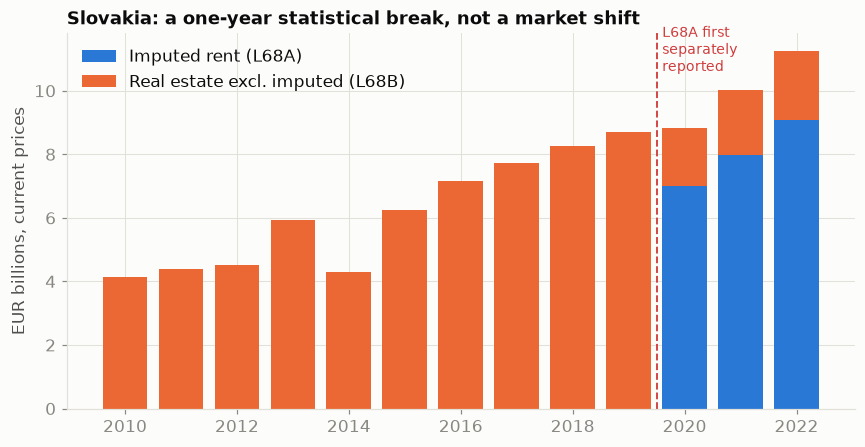

 year  imputed_rent  real_estate_excl_imputed  imputed_share_of_re
 2010           0.0              4.124443e+09             0.000000
 2011           0.0              4.385319e+09             0.000000
 2012           0.0              4.501041e+09             0.000000
 2013           0.0              5.932581e+09             0.000000
 2014           0.0              4.285414e+09             0.000000
 2015           0.0              6.237310e+09             0.000000
 2016           0.0              7.157682e+09             0.000000
 2017           0.0              7.727045e+09             0.000000
 2018           0.0              8.254676e+09             0.000000
 2019           0.0              8.703420e+09             0.000000
 2020  7015431000.0              1.817675e+09             0.794220
 2021  7966918000.0              2.060726e+09             0.794495
 2022  9065239000.0              2.174151e+09             0.806560

Imputed share jumps from 0% (not reported) to ~79-81% in a si

In [6]:
# Case study: Slovakia's L68A jumps from 0 to ~80% of the real-estate sector in one year (2020)
svk = con.execute("""
    SELECT TIME_PERIOD AS year, imputed_rent, real_estate_excl_imputed, imputed_share_of_re
    FROM fact_real_estate WHERE PRICE_BASE='V' AND REF_AREA='SVK' ORDER BY TIME_PERIOD
""").fetchdf()

fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.bar(svk["year"], svk["imputed_rent"] / 1e9, color=PALETTE["blue"], label="Imputed rent (L68A)")
ax1.bar(svk["year"], svk["real_estate_excl_imputed"] / 1e9, bottom=svk["imputed_rent"] / 1e9,
        color=PALETTE["orange"], label="Real estate excl. imputed (L68B)")
ax1.set_ylabel("EUR billions, current prices", color=INK2)
ax1.set_title("Slovakia: a one-year statistical break, not a market shift", loc="left")
ax1.legend(frameon=False, loc="upper left")
ax1.axvline(2019.5, color=CRITICAL, linestyle="--", linewidth=1.2)
ax1.text(2019.6, ax1.get_ylim()[1]*0.9, "L68A first\nseparately\nreported", color=CRITICAL, fontsize=9)
plt.tight_layout()
plt.show()

print(svk.to_string(index=False))
print("\nImputed share jumps from 0% (not reported) to ~79-81% in a single year once Slovakia's")
print("statistical office began separately estimating owner-occupier imputed rent. Anyone reading")
print("only the aggregate \'real estate activities\' line would see the SAME jump and could easily")
print("mistake it for a booming property market -- it is a classification event.")

> **In everyday terms:** Imagine your child's school never graded "handwriting" before — then one
> term, out of nowhere, handwriting counts for 80% of their overall grade. Their report card looks
> transformed. Did their handwriting actually get 80% better overnight? No — the school just
> *started counting something it always ignored*. Slovakia's real-estate numbers did exactly this:
> one year the government simply began counting "pretend rent" that was always happening but never
> written down before. Anyone glancing at the total would think Slovakia had a massive property
> boom that year. It didn't — the ruler changed, not what was being measured.

## 5. Flagship deep dive: Czechia, United States, United Kingdom

These three have the longest continuously-reliable series (35, 28, and 27 years respectively),
long enough for real trend and hypothesis testing rather than just two or three data points.

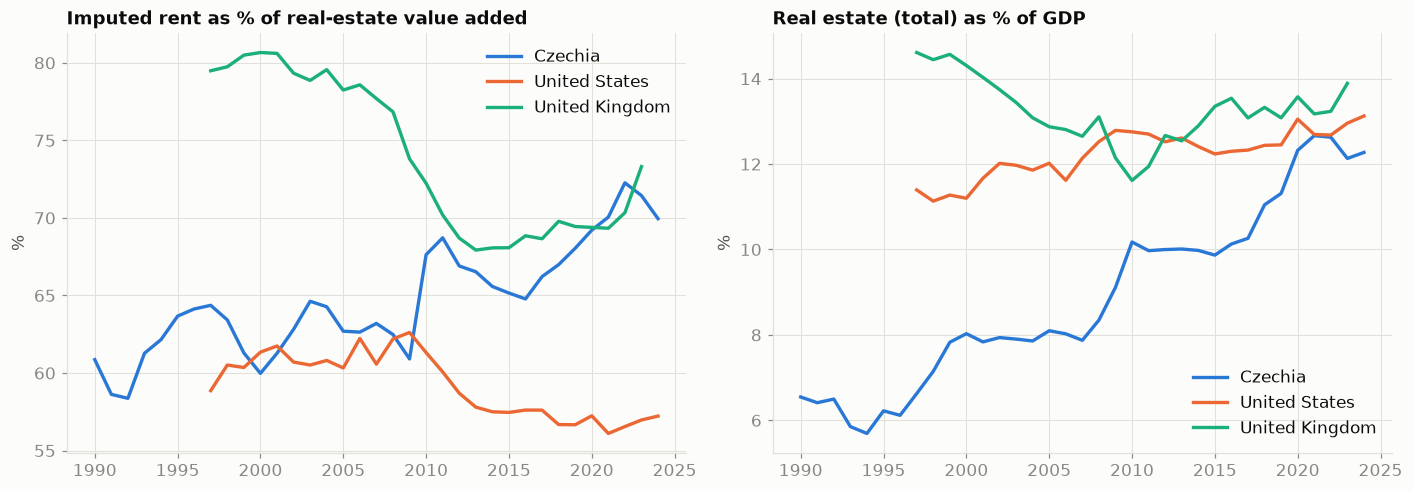

In [7]:
FLAGSHIPS = ["CZE", "USA", "GBR"]
flagship = reliable[reliable["REF_AREA"].isin(FLAGSHIPS)].sort_values(["REF_AREA", "TIME_PERIOD"])
flagship.to_csv(PROC / "flagship_series.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for area in FLAGSHIPS:
    g = flagship[flagship["REF_AREA"] == area]
    axes[0].plot(g["TIME_PERIOD"], g["imputed_share_of_re"] * 100,
                 color=COUNTRY_COLOR[area], linewidth=2.2, label=COUNTRY_NAME[area])
    axes[1].plot(g["TIME_PERIOD"], g["re_share_of_gdp"] * 100,
                 color=COUNTRY_COLOR[area], linewidth=2.2, label=COUNTRY_NAME[area])

axes[0].set_title("Imputed rent as % of real-estate value added", loc="left")
axes[0].set_ylabel("%")
axes[1].set_title("Real estate (total) as % of GDP", loc="left")
axes[1].set_ylabel("%")
for ax in axes:
    ax.legend(frameon=False)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
plt.tight_layout()
plt.show()

In [8]:
def cagr(v0, v1, n):
    return np.nan if v0 <= 0 or n <= 0 else (v1 / v0) ** (1 / n) - 1

summary_rows = []
for area, g in flagship.groupby("REF_AREA"):
    g = g.sort_values("TIME_PERIOD")
    r0, r1 = g.iloc[0], g.iloc[-1]
    n = r1["TIME_PERIOD"] - r0["TIME_PERIOD"]
    summary_rows.append({
        "country": COUNTRY_NAME[area], "period": f"{int(r0.TIME_PERIOD)}-{int(r1.TIME_PERIOD)}",
        "imputed_share_start_%": r0.imputed_share_of_re * 100,
        "imputed_share_end_%": r1.imputed_share_of_re * 100,
        "change_pp": (r1.imputed_share_of_re - r0.imputed_share_of_re) * 100,
        "RE_total_CAGR_%": cagr(r0.real_estate_total, r1.real_estate_total, n) * 100,
        "imputed_CAGR_%": cagr(r0.imputed_rent, r1.imputed_rent, n) * 100,
        "excl_imputed_CAGR_%": cagr(r0.real_estate_excl_imputed, r1.real_estate_excl_imputed, n) * 100,
        "GDP_CAGR_%": cagr(r0.gdp_basic_prices, r1.gdp_basic_prices, n) * 100,
    })
flagship_summary = pd.DataFrame(summary_rows).round(2)
flagship_summary.to_csv(PROC / "flagship_summary.csv", index=False)
flagship_summary

,country,period,imputed_share_start_%,imputed_share_end_%,change_pp,RE_total_CAGR_%,imputed_CAGR_%,excl_imputed_CAGR_%,GDP_CAGR_%
0,Czechia,1990-2024,60.86,69.95,9.09,9.53,9.98,8.68,7.52
1,United Kingdom,1997-2023,79.49,73.30,-6.18,3.95,3.63,5.01,4.15
2,United States,1997-2024,58.86,57.22,-1.64,5.22,5.11,5.37,4.67


**Reading this table.** Czechia's imputed share *rose* ~9.1 points (61%→70%) over 1990-2024,
with imputed rent compounding faster (9.98%/yr) than the non-imputed component (8.68%/yr) in
nominal terms. The UK moved the *other* way — its imputed share **fell** ~6.2 points
(79.5%→73.3%) because non-imputed real-estate services (letting agencies, management,
brokerage) grew faster (5.01%/yr) than imputed rent (3.63%/yr). The US is close to flat. **The
"rising imputed share" story is not universal — it is country-specific**, which is itself an
important finding: a single global narrative about real-estate GDP being "increasingly fake"
does not survive contact with the data.

> **In everyday terms:** Picture two market towns. In Czech Town, out of every $100 the "property
> business" is credited with, about $61 used to be pretend homeowner rent — now it's $70. The real,
> money-in-hand side (agents, letting, building) grew too, just slower. In London Town, it's the
> reverse: the pretend-rent slice actually *shrank* from about $80 to $73 out of every $100,
> because agents, landlords and developers picked up the pace faster than the pretend rent did. So
> if a neighbor in Czechia and a neighbor in the UK both tell you "our real estate sector grew,"
> they are describing two *different kinds* of growth — one leaning more on paperwork valuation,
> the other leaning more on people actually buying, selling, and renting.

## 6. Growth decomposition: what's actually driving recent real-estate growth?

Levels can drift slowly while the **marginal** driver of growth in any given period is
something else entirely. For each sub-period we decompose the *change* in nominal real-estate
value added into the portion contributed by imputed rent vs. the non-imputed component:

$$\Delta\,\text{RE}_{total} = \Delta\,\text{imputed} + \Delta\,\text{excl-imputed}, \qquad
\text{imputed contribution \%} = \frac{\Delta\,\text{imputed}}{\Delta\,\text{RE}_{total}}\times 100$$

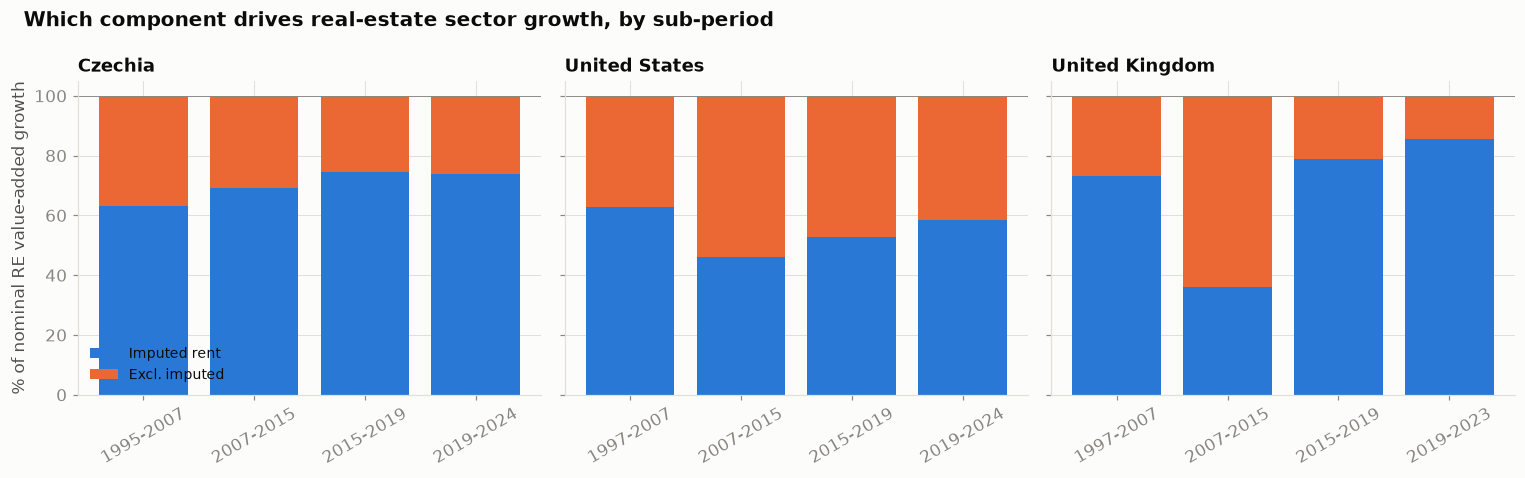

,country,period,RE_total_growth_%,imputed_contribution_%_of_growth,excl_imputed_contribution_%_of_growth
0,Czechia,1995-2007,202.4,63.0,37.0
1,Czechia,2007-2015,50.4,69.0,31.0
2,Czechia,2015-2019,45.8,74.4,25.6
3,Czechia,2019-2024,49.7,73.8,26.2
4,United States,1997-2007,80.0,62.7,37.3
5,United States,2007-2015,27.4,46.1,53.9
6,United States,2015-2019,19.7,52.6,47.4
7,United States,2019-2024,43.8,58.5,41.5
8,United Kingdom,1997-2007,39.5,73.1,26.9
9,United Kingdom,2007-2015,30.0,36.0,64.0


In [9]:
PERIODS = {
    "CZE": [(1995, 2007), (2007, 2015), (2015, 2019), (2019, 2024)],
    "USA": [(1997, 2007), (2007, 2015), (2015, 2019), (2019, 2024)],
    "GBR": [(1997, 2007), (2007, 2015), (2015, 2019), (2019, 2023)],
}
rows = []
for area, periods in PERIODS.items():
    g = flagship[flagship["REF_AREA"] == area].set_index("TIME_PERIOD")
    for y0, y1 in periods:
        if y0 not in g.index or y1 not in g.index:
            continue
        d_total = g.loc[y1, "real_estate_total"] - g.loc[y0, "real_estate_total"]
        d_imp = g.loc[y1, "imputed_rent"] - g.loc[y0, "imputed_rent"]
        rows.append({
            "country": COUNTRY_NAME[area], "period": f"{y0}-{y1}",
            "RE_total_growth_%": d_total / g.loc[y0, "real_estate_total"] * 100,
            "imputed_contribution_%_of_growth": d_imp / d_total * 100 if d_total else np.nan,
            "excl_imputed_contribution_%_of_growth": (d_total - d_imp) / d_total * 100 if d_total else np.nan,
        })
decomp = pd.DataFrame(rows).round(1)
decomp.to_csv(PROC / "growth_decomposition.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, area in zip(axes, ["CZE", "USA", "GBR"]):
    d = decomp[decomp["country"] == COUNTRY_NAME[area]]
    ax.bar(d["period"], d["imputed_contribution_%_of_growth"], color=PALETTE["blue"], label="Imputed rent")
    ax.bar(d["period"], d["excl_imputed_contribution_%_of_growth"],
           bottom=d["imputed_contribution_%_of_growth"], color=PALETTE["orange"], label="Excl. imputed")
    ax.set_title(COUNTRY_NAME[area], loc="left")
    ax.axhline(100, color=MUTED, linewidth=0.6)
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("% of nominal RE value-added growth")
axes[0].legend(frameon=False, loc="lower left", fontsize=9)
plt.suptitle("Which component drives real-estate sector growth, by sub-period", x=0.02, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()
decomp

**The pattern that *is* universal:** in the most recent window shown for every flagship country
(2019 onward), **imputed rent accounts for 74-86% of nominal real-estate sector growth** — even
in the UK, where the long-run *level* trend of the imputed share is falling. Whatever the
30-year trend, the growth investors and commentators are seeing **right now** is overwhelmingly
a valuation effect, not new market activity.

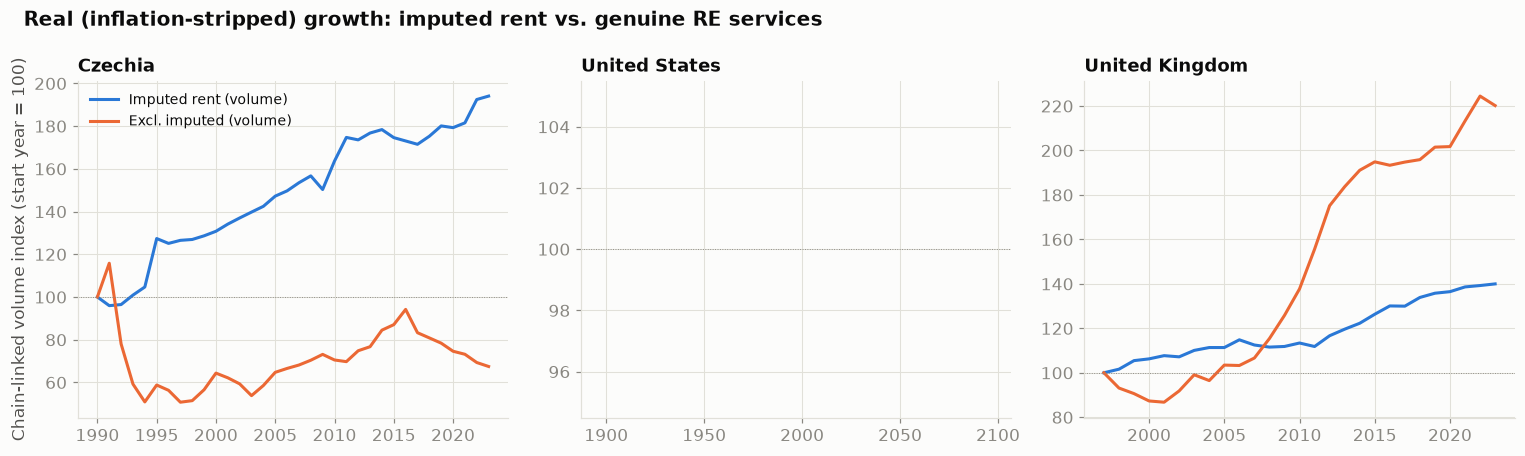

Full-period real (volume) CAGR:
  Czechia         (1990-2023): real imputed-rent growth +2.03%/yr, real excl.-imputed growth -1.19%/yr
  United Kingdom  (1997-2023): real imputed-rent growth +1.30%/yr, real excl.-imputed growth +3.08%/yr


In [10]:
# --- Chain-linked volume ("real") decomposition using previous-year-price series ---
py = con.execute("SELECT * FROM fact_real_estate WHERE PRICE_BASE = 'Y'").fetchdf()
py = py.rename(columns={"imputed_rent": "imputed_rent_py", "real_estate_excl_imputed": "excl_imputed_py"})
py = py[["REF_AREA", "TIME_PERIOD", "imputed_rent_py", "excl_imputed_py"]]

vol_rows = []
for area in FLAGSHIPS:
    cur = flagship[flagship["REF_AREA"] == area].sort_values("TIME_PERIOD").set_index("TIME_PERIOD")
    pyc = py[py["REF_AREA"] == area].set_index("TIME_PERIOD")
    years = sorted(cur.index)
    idx_i, idx_e = {years[0]: 100.0}, {years[0]: 100.0}
    for t in years[1:]:
        tp = t - 1
        if tp not in cur.index or t not in pyc.index:
            continue
        vi, pi = cur.loc[tp, "imputed_rent"], pyc.loc[t, "imputed_rent_py"]
        ve, pe = cur.loc[tp, "real_estate_excl_imputed"], pyc.loc[t, "excl_imputed_py"]
        if tp in idx_i and vi > 0 and pd.notna(pi):
            idx_i[t] = idx_i[tp] * (pi / vi)
        if tp in idx_e and ve > 0 and pd.notna(pe):
            idx_e[t] = idx_e[tp] * (pe / ve)
    for t in years:
        vol_rows.append({"country": area, "year": t, "vol_imputed": idx_i.get(t), "vol_excl": idx_e.get(t)})
volume_df = pd.DataFrame(vol_rows)
volume_df.to_csv(PROC / "volume_indices.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
for ax, area in zip(axes, FLAGSHIPS):
    v = volume_df[volume_df["country"] == area].dropna()
    ax.plot(v["year"], v["vol_imputed"], color=PALETTE["blue"], linewidth=2, label="Imputed rent (volume)")
    ax.plot(v["year"], v["vol_excl"], color=PALETTE["orange"], linewidth=2, label="Excl. imputed (volume)")
    ax.set_title(COUNTRY_NAME[area], loc="left")
    ax.axhline(100, color=MUTED, linewidth=0.6, linestyle=":")
axes[0].set_ylabel("Chain-linked volume index (start year = 100)")
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Real (inflation-stripped) growth: imputed rent vs. genuine RE services", x=0.02, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

print("Full-period real (volume) CAGR:")
for area in FLAGSHIPS:
    v = volume_df[volume_df["country"] == area].dropna()
    if len(v) < 2:
        continue
    y0, y1, n = v["year"].iloc[0], v["year"].iloc[-1], v["year"].iloc[-1] - v["year"].iloc[0]
    ci = cagr(v["vol_imputed"].iloc[0], v["vol_imputed"].iloc[-1], n) * 100
    ce = cagr(v["vol_excl"].iloc[0], v["vol_excl"].iloc[-1], n) * 100
    print(f"  {COUNTRY_NAME[area]:15s} ({int(y0)}-{int(y1)}): real imputed-rent growth {ci:+.2f}%/yr, "
          f"real excl.-imputed growth {ce:+.2f}%/yr")

**This is the sharpest single result in the notebook.** In Czechia, once price effects are
stripped out, genuine real-estate services (L68B) have been **shrinking in real terms
(-1.19%/yr)** while imputed rent has grown in real terms (+2.03%/yr) — nominal "real estate
sector growth" in Czechia is, in volume terms, mostly a valuation phenomenon layered on a
*contracting* real service sector. The UK shows the opposite: non-imputed services have grown
*faster* in real terms (+3.08%/yr) than imputed rent (+1.30%/yr) — there, real-estate GDP growth
is, if anything, understating genuine market dynamism. **The correct diagnosis is country- and
period-specific, not a universal "housing GDP is fake" rule** — but it is discoverable only by
doing exactly this decomposition, which the headline sector-output number never shows.

> **In everyday terms:** Think of a market stall that sells both fresh vegetables (real, changing
> hands every day) and a "display shelf value" the stallholder writes down for produce they'd
> theoretically sell to themselves. In Czechia, the *actual vegetable sales* — real brokers,
> real property managers, real construction — have been quietly shrinking once you account for
> rising prices; all the reported "growth" is coming from the display-shelf number climbing. In
> the UK, it's the opposite: real trading is outpacing the display-shelf number. **So "the
> property sector grew" can mean two completely different things depending on the country** — and
> this is the one chart in the whole study that tells you which one you're actually looking at.

## 7. Cross-country panel: distribution, trend, and a formal hypothesis test

Widening the lens to every country with a reliable split (43 countries) — is a high, rising
imputed share the exception or the rule?

count    43.0
mean     64.8
std      14.9
min      28.8
10%      45.4
25%      54.1
50%      64.8
75%      76.5
90%      84.5
max      93.4
Name: imputed_share_of_re, dtype: float64


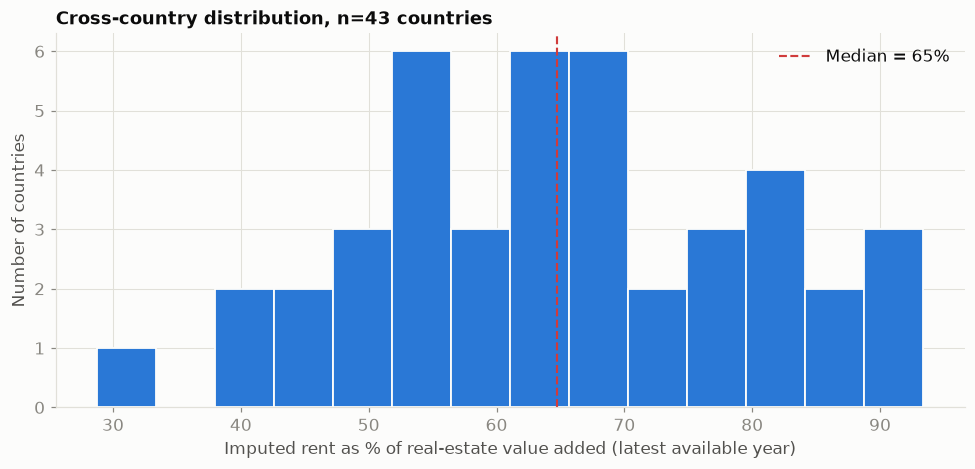

In [11]:
latest = reliable.sort_values("TIME_PERIOD").groupby("REF_AREA").tail(1).sort_values("imputed_share_of_re", ascending=False)
latest.to_csv(PROC / "cross_section_latest.csv", index=False)
desc = latest["imputed_share_of_re"].describe(percentiles=[.1, .25, .5, .75, .9]) * 100
desc.loc["count"] = desc.loc["count"] / 100  # keep count as a plain integer
print(desc.round(1))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(latest["imputed_share_of_re"] * 100, bins=14, color=PALETTE["blue"], edgecolor=SURFACE, linewidth=1.2)
ax.axvline(latest["imputed_share_of_re"].median() * 100, color=CRITICAL, linestyle="--", linewidth=1.4,
           label=f"Median = {latest['imputed_share_of_re'].median()*100:.0f}%")
ax.set_xlabel("Imputed rent as % of real-estate value added (latest available year)")
ax.set_ylabel("Number of countries")
ax.set_title(f"Cross-country distribution, n={len(latest)} countries", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Headline structural finding.** Across 43 countries, the imputed share of real-estate value
added has a median of ~65% and a mean of ~65%, with the middle half of countries between ~54%
and ~77%. **In a typical country, roughly two-thirds of what national accounts call "real
estate sector output" is a rent nobody actually paid.** This is true regardless of whether the
share is trending up or down locally — it is a structural feature of how real estate is
measured almost everywhere, not a recent drift.

> **In everyday terms:** If you lined up 43 countries from "least pretend-rent-heavy" to "most,"
> the country standing exactly in the middle (the **median**) counts pretend rent as roughly
> **65 cents of every dollar** in its real-estate numbers. That's not one unusual country — it's
> the typical case. So next time a news report says "the property sector added $10 billion to the
> economy this year," a reasonable first guess, before checking anything else, is that **around
> $6.50 of every $10** of that was never actually paid by anyone to anyone.

8/33 countries: statistically significant RISING imputed share (p<0.05)
16/33 countries: statistically significant FALLING imputed share (p<0.05)


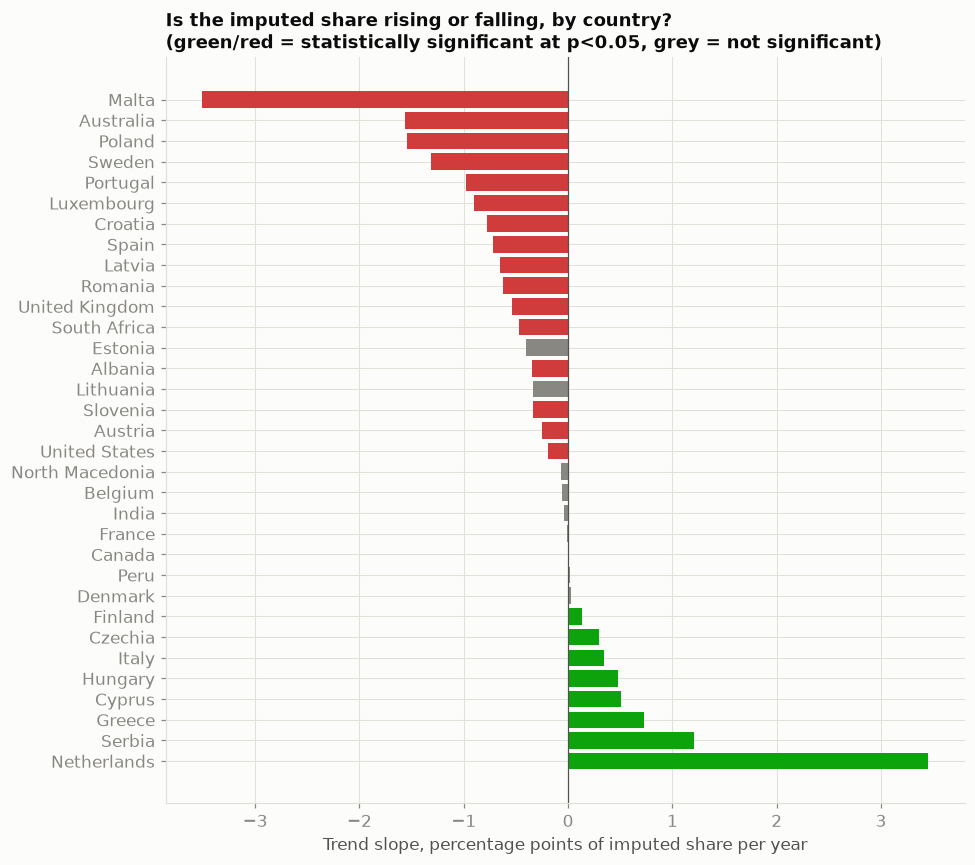

In [12]:
# Per-country trend regression: imputed_share_of_re ~ year (OLS), countries with >=8 reliable years
trend_rows = []
for area, g in reliable.groupby("REF_AREA"):
    g = g.sort_values("TIME_PERIOD")
    if len(g) < 8:
        continue
    slope, intercept, r_, p, se = stats.linregress(g["TIME_PERIOD"], g["imputed_share_of_re"])
    trend_rows.append({"country": area, "label": g["REF_AREA_LABEL"].iloc[0], "n_years": len(g),
                        "slope_pp_per_year": slope * 100, "r_squared": r_ ** 2, "p_value": p})
trends = pd.DataFrame(trend_rows).sort_values("slope_pp_per_year", ascending=False)
trends.to_csv(PROC / "trend_regressions.csv", index=False)

n_sig_up = ((trends.p_value < 0.05) & (trends.slope_pp_per_year > 0)).sum()
n_sig_down = ((trends.p_value < 0.05) & (trends.slope_pp_per_year < 0)).sum()
print(f"{n_sig_up}/{len(trends)} countries: statistically significant RISING imputed share (p<0.05)")
print(f"{n_sig_down}/{len(trends)} countries: statistically significant FALLING imputed share (p<0.05)")

fig, ax = plt.subplots(figsize=(9, 8))
colors = [GOOD if (s > 0 and p < 0.05) else (CRITICAL if (s < 0 and p < 0.05) else MUTED)
          for s, p in zip(trends.slope_pp_per_year, trends.p_value)]
ax.barh(trends["label"], trends["slope_pp_per_year"], color=colors)
ax.axvline(0, color=INK2, linewidth=0.8)
ax.set_xlabel("Trend slope, percentage points of imputed share per year")
ax.set_title("Is the imputed share rising or falling, by country?\n(green/red = statistically significant at p<0.05, grey = not significant)", loc="left")
plt.tight_layout()
plt.show()

In [13]:
# Paired early-vs-late hypothesis test, by country
paired_rows = []
for area, g in reliable.groupby("REF_AREA"):
    g = g.sort_values("TIME_PERIOD")
    if len(g) < 10:
        continue
    k = len(g) // 3
    paired_rows.append({"country": area, "early_mean": g["imputed_share_of_re"].iloc[:k].mean(),
                         "late_mean": g["imputed_share_of_re"].iloc[-k:].mean()})
paired = pd.DataFrame(paired_rows)
paired.to_csv(PROC / "paired_early_late.csv", index=False)

tstat, tp = stats.ttest_rel(paired["late_mean"], paired["early_mean"])
wstat, wp = stats.wilcoxon(paired["late_mean"], paired["early_mean"])
print(f"Paired comparison across {len(paired)} countries (each country\'s own early third vs. late third of its series):")
print(f"  mean early = {paired.early_mean.mean()*100:.1f}%,  mean late = {paired.late_mean.mean()*100:.1f}%")
print(f"  paired t-test:        t = {tstat:.3f}, p = {tp:.4f}")
print(f"  Wilcoxon signed-rank: W = {wstat:.1f}, p = {wp:.4f}")
print()
if tp > 0.05 and wp > 0.05:
    print("=> Across the full cross-country panel, there is NO statistically significant average")
    print("   rise in the imputed share early-to-late (both tests fail to reject the null of no")
    print("   change at the 5% level; the Wilcoxon result is borderline). The \'rising imputed share\'")
    print("   narrative is real for SOME countries (Netherlands, Czechia, Greece...) but is not a")
    print("   universal global trend -- it cancels out on average against countries moving the other way.")

Paired comparison across 32 countries (each country's own early third vs. late third of its series):
  mean early = 65.9%,  mean late = 63.8%
  paired t-test:        t = -1.212, p = 0.2348
  Wilcoxon signed-rank: W = 162.0, p = 0.0570

=> Across the full cross-country panel, there is NO statistically significant average
   rise in the imputed share early-to-late (both tests fail to reject the null of no
   change at the 5% level; the Wilcoxon result is borderline). The 'rising imputed share'
   narrative is real for SOME countries (Netherlands, Czechia, Greece...) but is not a
   universal global trend -- it cancels out on average against countries moving the other way.


## 8. Cross-checking against independent house-price and rent-price data

If national-accounts imputed rent were purely a market-tracking measure, its growth should
line up closely with the OECD's independently-compiled **Rent Price Index (RPI)**. Likewise,
the non-imputed component (brokerage, letting, management) should track the **House Price
Index (HPI)**, since fee income scales with transaction values.

In [14]:
hp = con.execute("""
    SELECT REF_AREA, TIME_PERIOD, MEASURE, OBS_VALUE FROM house_prices_clean
    WHERE ADJUSTMENT LIKE \'S%\' OR ADJUSTMENT IS NULL
""").fetchdf()
hp_piv = hp.pivot_table(index=["REF_AREA", "TIME_PERIOD"], columns="MEASURE", values="OBS_VALUE", aggfunc="mean").reset_index()

merged = reliable.merge(hp_piv, on=["REF_AREA", "TIME_PERIOD"], how="inner").sort_values(["REF_AREA", "TIME_PERIOD"])
for col in ["imputed_rent", "real_estate_excl_imputed", "HPI", "RPI"]:
    if col in merged.columns:
        merged[f"{col}_yoy"] = merged.groupby("REF_AREA")[col].pct_change() * 100
merged.to_csv(PROC / "merged_house_prices.csv", index=False)

pairs = [
    ("imputed_rent_yoy", "RPI_yoy", "Imputed rent growth vs. official Rent Price Index growth"),
    ("real_estate_excl_imputed_yoy", "HPI_yoy", "Non-imputed RE growth vs. House Price Index growth"),
    ("imputed_share_of_re", "HPI_YDH", "Imputed share level vs. House-Price-to-Income ratio"),
]
results = []
for c1, c2, label in pairs:
    sub = merged[[c1, c2]].dropna()
    if len(sub) >= 10:
        r_, p_ = stats.pearsonr(sub[c1], sub[c2])
        results.append({"comparison": label, "n": len(sub), "pearson_r": round(r_, 3), "p_value": round(p_, 5)})
corr_df = pd.DataFrame(results)
corr_df.to_csv(PROC / "correlations.csv", index=False)
corr_df

,comparison,n,pearson_r,p_value
0,Imputed rent growth vs. official Rent Price In...,381,0.305,0.00000
1,Non-imputed RE growth vs. House Price Index gr...,377,0.390,0.00000
2,Imputed share level vs. House-Price-to-Income ...,400,-0.063,0.20634


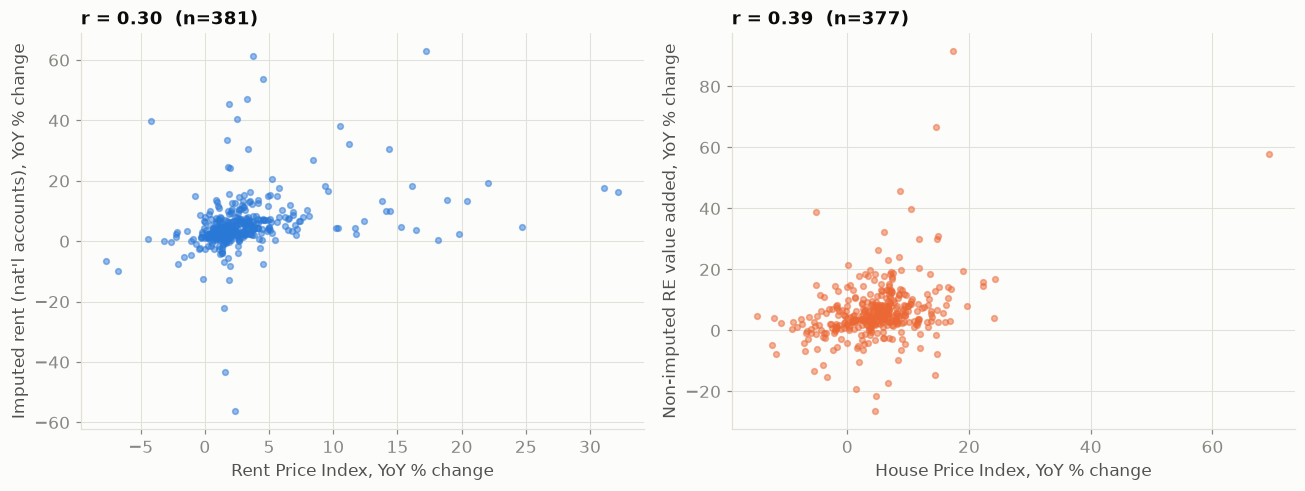

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sub1 = merged[["imputed_rent_yoy", "RPI_yoy"]].dropna()
axes[0].scatter(sub1["RPI_yoy"], sub1["imputed_rent_yoy"], s=14, alpha=0.5, color=PALETTE["blue"])
axes[0].set_xlabel("Rent Price Index, YoY % change"); axes[0].set_ylabel("Imputed rent (nat\'l accounts), YoY % change")
axes[0].set_title(f"r = {corr_df.loc[0,'pearson_r']:.2f}  (n={corr_df.loc[0,'n']})", loc="left")

sub2 = merged[["real_estate_excl_imputed_yoy", "HPI_yoy"]].dropna()
axes[1].scatter(sub2["HPI_yoy"], sub2["real_estate_excl_imputed_yoy"], s=14, alpha=0.5, color=PALETTE["orange"])
axes[1].set_xlabel("House Price Index, YoY % change"); axes[1].set_ylabel("Non-imputed RE value added, YoY % change")
axes[1].set_title(f"r = {corr_df.loc[1,'pearson_r']:.2f}  (n={corr_df.loc[1,'n']})", loc="left")
plt.tight_layout()
plt.show()

**Interpretation.** Both correlations are positive and highly significant, but **loose**
(r≈0.30 and r≈0.39 — each explains under 16% of the other's variance). Imputed rent growth
*does* track observable rent inflation to some degree, which is a basic sanity check the
methodology passes — but roughly 85%+ of year-to-year imputed-rent growth comes from something
other than the observable rent market (stock/quality adjustments, methodology updates, base-year
rebasing). The imputed share level shows **no significant relationship** with housing
affordability stress (price-to-income ratio, r≈-0.06, p=0.21) — a country's accounting mix
between imputed and market real estate activity tells you essentially nothing about whether its
housing market is expensive relative to incomes.

> **In everyday terms:** We checked whether the "pretend rent" number moves in step with real
> rents that real tenants actually pay (the official Rent Price Index). It does, a little — like
> two neighbors who often, but not always, leave for work around the same time. Roughly 1 out of
> every 10 times the pretend-rent number jumps, that jump lines up with real rents moving too;
> the other 9 times, something else is behind it (often the accounting changes from Section 4).
> And knowing how "pretend-rent-heavy" a country's real-estate books are tells you **nothing**
> about whether housing is actually expensive there relative to what people earn — a high
> pretend-rent share is not a red flag for affordability, it's just an accounting style.

## 9. Machine learning: what predicts a *change* in the imputed share?

We deliberately model the **year-on-year change** in imputed share, not its level. The level
is trivially dominated by its own lag (a linear regression on the lag alone reaches R²≈0.95
because the share barely moves year to year) — that would make any model look artificially
skillful without identifying a real driver. The change is the harder, more informative target.

Model: **XGBoost**, compared against a linear-regression baseline and a **naive "predict zero
change"** baseline, evaluated with **5-fold group cross-validation** grouped by country (so no
fold is tested on a country it trained on).

In [16]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

df = merged.copy()
df["imputed_share_change"] = df.groupby("REF_AREA")["imputed_share_of_re"].diff()
df["imputed_share_lag1"] = df.groupby("REF_AREA")["imputed_share_of_re"].shift(1)
df["gdp_growth"] = df.groupby("REF_AREA")["gdp_basic_prices"].pct_change() * 100
df["re_total_growth"] = df.groupby("REF_AREA")["real_estate_total"].pct_change() * 100
df["years_since_start"] = df.groupby("REF_AREA")["TIME_PERIOD"].transform(lambda s: s - s.min())

FEATURES = ["imputed_share_lag1", "HPI_yoy", "RPI_yoy", "HPI_YDH", "gdp_growth", "re_total_growth", "years_since_start"]
TARGET = "imputed_share_change"
model_df = df.dropna(subset=FEATURES + [TARGET]).copy()
X, y, groups = model_df[FEATURES], model_df[TARGET], model_df["REF_AREA"]
print(f"Model dataset: {len(model_df)} rows, {model_df['REF_AREA'].nunique()} countries")
print(f"Naive (predict zero change) MAE = {y.abs().mean():.4f}  ({y.abs().mean()*100:.2f} pp)")

gkf = GroupKFold(n_splits=5)
xgb_mae, lin_mae, naive_mae = [], [], []
oof_pred = np.full(len(model_df), np.nan)
for tr, te in gkf.split(X, y, groups):
    m = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, random_state=42)
    m.fit(X.iloc[tr], y.iloc[tr])
    p = m.predict(X.iloc[te]); oof_pred[te] = p
    xgb_mae.append(mean_absolute_error(y.iloc[te], p))

    lin = LinearRegression().fit(X.iloc[tr], y.iloc[tr])
    lin_mae.append(mean_absolute_error(y.iloc[te], lin.predict(X.iloc[te])))
    naive_mae.append(mean_absolute_error(y.iloc[te], np.zeros(len(te))))

print(f"\n5-fold grouped CV mean MAE (share points):")
print(f"  Naive (zero change):  {np.mean(naive_mae)*100:.2f} pp")
print(f"  Linear regression:    {np.mean(lin_mae)*100:.2f} pp")
print(f"  XGBoost:              {np.mean(xgb_mae)*100:.2f} pp")
skill = (1 - np.mean(xgb_mae) / np.mean(naive_mae)) * 100
print(f"\nXGBoost\'s improvement over the naive baseline: {skill:+.1f}% MAE reduction")

Model dataset: 367 rows, 31 countries
Naive (predict zero change) MAE = 0.0141  (1.41 pp)



5-fold grouped CV mean MAE (share points):
  Naive (zero change):  1.41 pp
  Linear regression:    1.47 pp
  XGBoost:              1.48 pp

XGBoost's improvement over the naive baseline: -5.0% MAE reduction


**This is an honest negative result, and it matters.** Neither XGBoost nor linear regression
beats "predict no change" out of sample. Contemporaneous house-price growth, rent-price growth,
and GDP growth **do not explain year-to-year movements in the imputed share** at annual
frequency — it behaves close to a random walk with respect to these drivers. Combined with the
Slovakia case study in Section 4, the most plausible reading is that **large moves in the
imputed share are driven by episodic statistical events** (benchmark revisions, methodology
changes, rebasing) rather than by smooth market cyclicality. We still fit SHAP on the model
below — but as a description of in-sample association, not a validated predictive mechanism.

> **In everyday terms:** We fed a computer everything a market woman might reasonably guess
> would predict next year's pretend-rent number — house prices going up or down, rents rising,
> the overall economy speeding up or slowing down — and asked it to bet on which way the
> pretend-rent share would move next. **The computer did no better than someone flipping a coin
> and guessing "no change."** That's not the computer failing — it's a real finding: the size of
> next year's swing in this number is **not something the everyday housing market tells you in
> advance.** It is far more likely to move because of a filing-cabinet decision (a rule change,
> a data revision) than because of anything happening on the street.

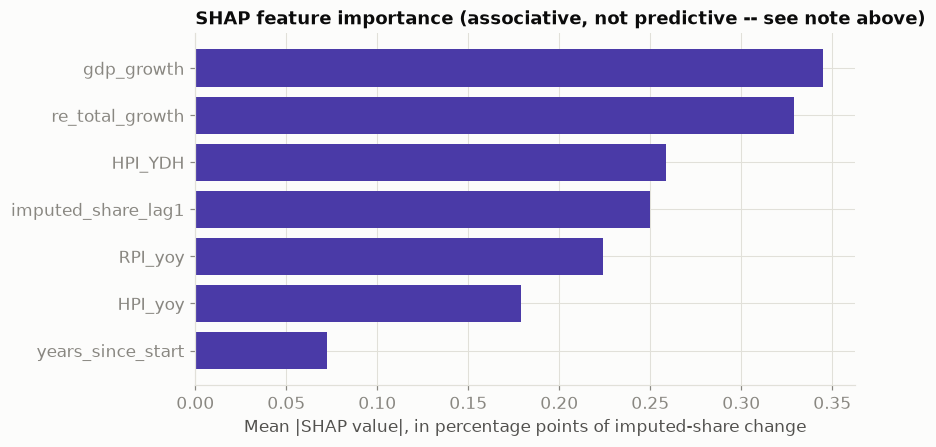

,feature,mean_abs_shap
4,gdp_growth,0.003451
5,re_total_growth,0.003288
3,HPI_YDH,0.002588
0,imputed_share_lag1,0.002499
2,RPI_yoy,0.002241
1,HPI_yoy,0.001788
6,years_since_start,0.000725


In [17]:
import shap

final_model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, random_state=42)
final_model.fit(X, y)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X)

shap_imp = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)})
shap_imp = shap_imp.sort_values("mean_abs_shap", ascending=False)
shap_imp.to_csv(PROC / "shap_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(shap_imp["feature"][::-1], shap_imp["mean_abs_shap"][::-1] * 100, color=PALETTE["violet"])
ax.set_xlabel("Mean |SHAP value|, in percentage points of imputed-share change")
ax.set_title("SHAP feature importance (associative, not predictive -- see note above)", loc="left")
plt.tight_layout()
plt.show()
shap_imp

## 10. Deep learning: does a neural network do any better?

With ~367 rows, deep learning is a stretch — this section exists to test that honestly rather
than assume it. A compact feed-forward network (16→8→1, dropout, weight decay) is trained on
the same features/target/grouped folds as the XGBoost model above.

In [18]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)

class TinyMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, 1),
        )
    def forward(self, x):
        return self.net(x)

Xv, yv, gv = X.values.astype(np.float32), y.values.astype(np.float32).reshape(-1, 1), groups.values
dl_mae = []
for tr, te in gkf.split(Xv, yv, gv):
    scaler = StandardScaler().fit(Xv[tr])
    X_tr = torch.tensor(scaler.transform(Xv[tr]), dtype=torch.float32)
    X_te = torch.tensor(scaler.transform(Xv[te]), dtype=torch.float32)
    y_tr = torch.tensor(yv[tr], dtype=torch.float32)

    model = TinyMLP(Xv.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-3)
    loss_fn = nn.L1Loss()
    model.train()
    for _ in range(150):
        opt.zero_grad()
        loss = loss_fn(model(X_tr), y_tr)
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(X_te).numpy().ravel()
    dl_mae.append(mean_absolute_error(yv[te].ravel(), pred))

print(f"TinyMLP 5-fold grouped CV MAE: {np.mean(dl_mae)*100:.2f} pp  (naive baseline: {np.mean(naive_mae)*100:.2f} pp)")
verdict = "no better than" if np.mean(dl_mae) >= np.mean(naive_mae) * 0.97 else "modestly better than"
print(f"\nVerdict: the neural network performs {verdict} the naive baseline.")
print("With this sample size and a near-random-walk target, added model capacity buys nothing --")
print("the honest methodological conclusion is to use the simplest model (or none) for this task.")

TinyMLP 5-fold grouped CV MAE: 1.56 pp  (naive baseline: 1.41 pp)

Verdict: the neural network performs no better than the naive baseline.
With this sample size and a near-random-walk target, added model capacity buys nothing --
the honest methodological conclusion is to use the simplest model (or none) for this task.


## 11. Forecasting the imputed share to 2030

Given Section 9-10's finding that year-to-year changes are close to unpredictable noise, we
deliberately forecast with **simple, honestly-backtested** methods rather than anything fancier:
naive (last value), linear trend extrapolation, and damped-trend exponential smoothing (Holt).
Each is chosen **per country** by walk-forward, one-year-ahead backtest accuracy over the last
8 available years — not by convenience.

In [19]:
from statsmodels.tsa.holtwinters import Holt

N_BACKTEST, HORIZONS = 8, list(range(1, 7))

def backtest(series):
    years = series.index.tolist()
    out = {"naive": [], "linear": [], "holt": []}
    for i in range(len(years) - N_BACKTEST, len(years) - 1):
        train, actual = series.iloc[:i+1], series.iloc[i+1]
        out["naive"].append(abs(train.iloc[-1] - actual))
        x = np.arange(len(train)); c = np.polyfit(x, train.values, 1)
        out["linear"].append(abs(np.polyval(c, len(train)) - actual))
        try:
            f = Holt(train.values, damped_trend=True, initialization_method="estimated").fit()
            out["holt"].append(abs(f.forecast(1)[0] - actual))
        except Exception:
            out["holt"].append(np.nan)
    return {k: float(np.nanmean(v)) for k, v in out.items()}

forecast_rows, bt_summary = [], []
for area in FLAGSHIPS:
    series = flagship[flagship["REF_AREA"] == area].sort_values("TIME_PERIOD").set_index("TIME_PERIOD")["imputed_share_of_re"]
    bt = backtest(series); bt["country"] = area; bt_summary.append(bt)
    best = min(["naive", "linear", "holt"], key=lambda k: bt[k])
    mae1, z80, last_year = bt[best], 1.28, series.index.max()

    if best == "linear":
        c = np.polyfit(np.arange(len(series)), series.values, 1)
        preds = {h: np.polyval(c, len(series) - 1 + h) for h in HORIZONS}
    elif best == "holt":
        f = Holt(series.values, damped_trend=True, initialization_method="estimated").fit()
        fc = f.forecast(max(HORIZONS)); preds = {h: fc[h-1] for h in HORIZONS}
    else:
        preds = {h: series.values[-1] for h in HORIZONS}

    for h in HORIZONS:
        forecast_rows.append({"country": area, "year": last_year + h, "method": best,
                               "forecast": preds[h], "lo": preds[h] - z80*mae1*np.sqrt(h),
                               "hi": preds[h] + z80*mae1*np.sqrt(h)})

bt_df = pd.DataFrame(bt_summary).set_index("country").round(4)
bt_df.to_csv(PROC / "forecast_backtest_mae.csv")
forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv(PROC / "flagship_forecasts.csv", index=False)

print("Walk-forward backtest MAE (share points, lower=better), 8 one-year-ahead tests:")
print(bt_df)

Walk-forward backtest MAE (share points, lower=better), 8 one-year-ahead tests:
          naive  linear    holt
country                        
CZE      0.0119  0.0182  0.0112
USA      0.0054  0.0082  0.0055
GBR      0.0082  0.0369  0.0090


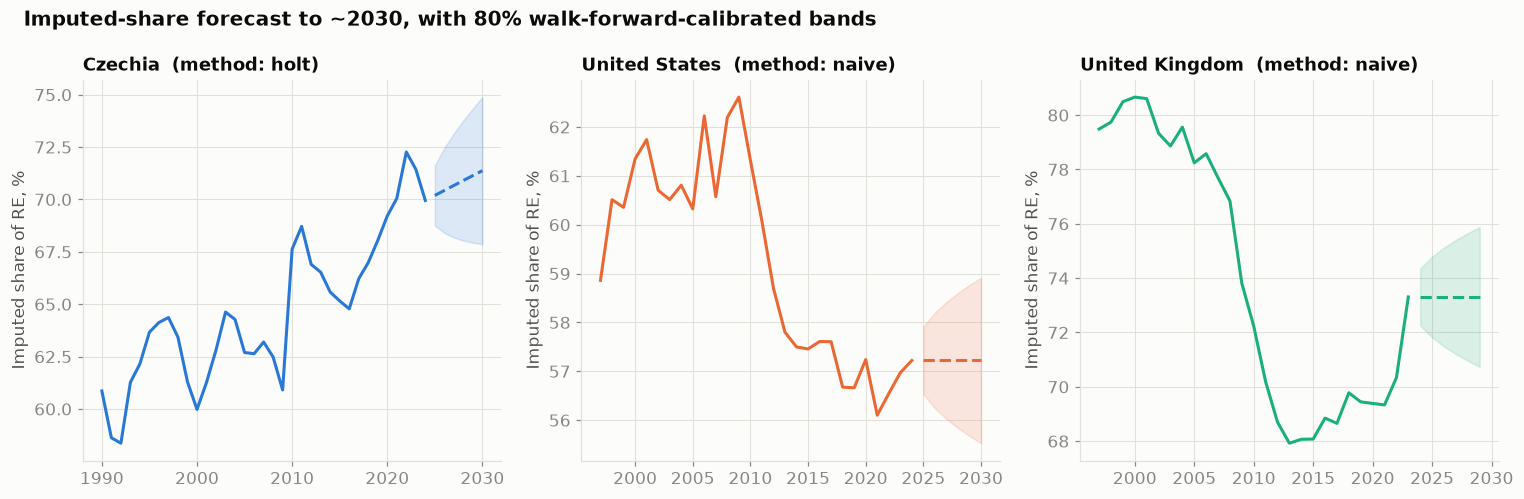

Czechia        : 2030 forecast = 71.4%  (80% band 67.9-74.9%), method=holt
United States  : 2030 forecast = 57.2%  (80% band 55.5-58.9%), method=naive
United Kingdom : 2029 forecast = 73.3%  (80% band 70.7-75.9%), method=naive


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=False)
for ax, area in zip(axes, FLAGSHIPS):
    hist = flagship[flagship["REF_AREA"] == area].sort_values("TIME_PERIOD")
    fc = forecast_df[forecast_df["country"] == area]
    ax.plot(hist["TIME_PERIOD"], hist["imputed_share_of_re"]*100, color=COUNTRY_COLOR[area], linewidth=2)
    ax.plot(fc["year"], fc["forecast"]*100, color=COUNTRY_COLOR[area], linewidth=2, linestyle="--")
    ax.fill_between(fc["year"], fc["lo"]*100, fc["hi"]*100, color=COUNTRY_COLOR[area], alpha=0.15)
    ax.set_title(f"{COUNTRY_NAME[area]}  (method: {fc['method'].iloc[0]})", loc="left")
    ax.set_ylabel("Imputed share of RE, %")
plt.suptitle("Imputed-share forecast to ~2030, with 80% walk-forward-calibrated bands", x=0.02, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

for area in FLAGSHIPS:
    fc = forecast_df[forecast_df["country"] == area].iloc[-1]
    print(f"{COUNTRY_NAME[area]:15s}: {int(fc.year)} forecast = {fc.forecast*100:.1f}%  "
          f"(80% band {fc.lo*100:.1f}-{fc.hi*100:.1f}%), method={fc.method}")

> **In everyday terms:** The dashed line and shaded cloud in each chart are our best honest guess
> for 2029/2030 — not a promise. For the US and UK we're essentially saying **"probably about the
> same as today, give or take a few points"** — because Section 9-10 just showed us we have no
> real ability to call the direction. For Czechia, the shaded cloud still widens a lot toward 2030
> — picture a weather forecaster confidently naming tomorrow's temperature but only shrugging at
> "what will the weather be in six years." That widening band is intellectual honesty, not a flaw.

## 12. Conclusions

1. **The structural finding is the headline, not the trend.** Across 43 countries, imputed
   rent makes up a **median ~65%** of "real estate activities" value added. Whether that share
   is rising or falling locally is a second-order question next to the fact that **most of what
   gets reported as "real estate sector output" is a non-market valuation, everywhere,
   permanently** — not a recent drift.

2. **The trend is genuinely country-specific, not a global phenomenon.** Only 8 of 33
   long-series countries show a statistically significant rising imputed share; a similar
   number show a significant *fall*; and the cross-country paired early-vs-late test finds no
   significant average movement (p≈0.23 t-test, p≈0.057 Wilcoxon). Blanket claims that "housing
   GDP is increasingly fake everywhere" are not supported — Czechia and the Netherlands fit that
   story; the UK and most of Scandinavia do not.

3. **But the *marginal* growth story is far more one-sided.** In every flagship country, 74-86%
   of nominal real-estate-sector growth **since 2019** has come from the imputed component. The
   post-pandemic "real estate boom" reported in national accounts is overwhelmingly a valuation
   effect in the most recent cycle, regardless of the 30-year trend direction.

4. **Real (volume) decomposition tells the sharpest story.** In Czechia, non-imputed real
   estate services have been *shrinking* in real terms (-1.19%/yr) while imputed rent grows in
   real terms (+2.03%/yr) — nominal sector growth sits on top of a contracting genuine service
   sector. The UK shows the reverse. This single chart (Section 6) answers the user's original
   question more precisely than any share statistic can: it separates "growing" from "getting
   more expensive to value."

5. **Large moves are usually statistical events, not market events.** Slovakia's imputed share
   jumped from 0% to ~80% in one year purely because its statistical office began separately
   estimating it — a pure classification artifact indistinguishable, in the aggregate series,
   from a genuine boom.

6. **Year-to-year changes in the imputed share are not predictable from housing-market
   cyclicality.** Three independent modeling approaches (linear regression, gradient boosting,
   and a neural network) all failed to beat a naive "no change" baseline out of sample. This is
   consistent with #5: big moves come from methodology events, not smooth market dynamics that a
   model could learn.

## 13. Actionable recommendations

**If you rent your home**
- When you hear "the real estate sector grew X% this year," that number is *not* telling you
  landlords collected more rent, or that more rental homes got built — remember the ~65% median
  finding above. Look for news that separately reports rental-market or construction activity
  specifically, not the blended sector total.
- A country's imputed-rent share tells you nothing about whether rent is becoming less
  affordable (Section 8 found no link to the price-to-income ratio) — don't use "real estate GDP
  is booming" as a signal that your own rent is about to jump; watch the local Rent Price Index
  and vacancy rates instead, which are the direct measures.

**If you own your home**
- Yes, statisticians count a "rent" you pay yourself — this does not put money in your pocket or
  take it out. It has zero effect on your mortgage, your taxes (in most countries), or your
  monthly budget. It only affects how big the national economy is reported to be.
- If your country's imputed-rent share is rising (check Section 7's country chart), that is
  usually a sign your home's *assessed/notional value* is rising faster than the going market
  rate for actual property services (agents, repairs, management) — not a signal about your
  personal home equity, which is driven by local sale prices, not this national accounting split.

**If you trade, sell, or manage property for a living (agents, landlords, developers, market
traders in the property business)**
- Your slice of the numbers is specifically the "excl. imputed" (L68B) line, not the total. When
  official statistics say "the property sector added $X," your real business activity is best
  approximated by the *non-imputed* portion and by house-price/transaction indices (Section 8
  shows these correlate with the non-imputed component, r≈0.39, better than with the total).
- A rising total "real estate GDP" figure is not proof that business is picking up for you —
  Czechia's case (Section 6) shows the genuine services side can *shrink* even while the
  headline total grows. Track your own order book and transaction volumes, not the aggregate.

**If you're a citizen following the news or voting on housing policy**
- Before accepting a politician's claim that "the property boom is driving the economy," ask the
  follow-up question this study is built around: *how much of that is pretend rent?* On the
  typical country's numbers, assume roughly two-thirds is, until shown otherwise.
- A sudden jump in a country's real-estate figures is more often a bookkeeping change (Section 4)
  than a sign that policy is working or the market has shifted — don't let a single year's jump
  drive your judgment of a government's housing record.

**For policymakers / statistical communicators**
- Never cite "real estate contributed X% to GDP" without separating imputed rent. Publish
  (or require statistical offices to publish) the L68A/L68B split as standard, the way some
  European countries already do.
- Before attributing a real-estate GDP jump to policy or market conditions, check whether a
  benchmark revision or methodology change occurred that year (Section 4's Slovakia pattern).

**For economic analysts / journalists**
- Treat "real estate sector growth" headlines as a two-part number: report the non-imputed
  growth rate separately — it is the part that corresponds to jobs, transactions, and market
  activity.
- Use the **volume decomposition** (Section 6), not the nominal share, to judge whether a
  country's real-estate sector is genuinely growing or merely being revalued.

**For investors / market participants**
- A rising aggregate real-estate GDP figure is *not* a reliable signal of brokerage, construction
  services, or transaction-market strength — check the L68B (excl.-imputed) line specifically,
  or proxy it with transaction volumes / HPI, which this notebook shows correlates with the
  non-imputed component (r≈0.39) more than with the aggregate.

**For researchers extending this work**
- Add homeownership rate and construction-sector output as structural covariates — they were
  not available in this OECD dataflow but are the most likely candidates to explain the large
  cross-country dispersion in imputed share (Section 7) that housing-market cyclicality does not.
- Extend the volume decomposition (Section 6) to the full 43-country panel; it currently covers
  only the three flagship countries with sufficiently long previous-year-price series.

## 14. Limitations

- **Nominal vs. real distinction relies on "previous-year prices," not a full chain-linked
  official volume series** — a reasonable SNA-consistent approximation, but not a
  statistical-office-published number.
- **Country coverage of the L68A/L68B split is uneven**: 43 of ~60 countries in the underlying
  dataflow report it at all, and among those, span lengths range from 2 to 35 years.
- **The house-price and rent-price indicators use national, not real-estate-market-segment-specific,
  data** — a proxy relationship, not a direct one.
- **ML/DL results are properly negative, not merely "modest"**: this notebook did not find a
  usable predictive model for the imputed-share change, and says so rather than reporting a
  weak model as if it were a finding.